# Forecasting SPY’s Next-Week Risk
**DAT 402 Project 1 · A time-series regression study**

Can market conditions improve forecasts of how much SPY will fluctuate over the next five trading sessions? This project compares Ridge and Random Forest with two recent-volatility baselines, using a new 2026 holdout after model choices were frozen.

On 169 test forecasts, Ridge and Random Forest achieve RMSE of **4.22 and 4.29 annualized volatility percentage points**, versus **6.17 and 5.71** for the two baselines. The result concerns risk magnitude, not whether SPY will rise, and the short test period limits generalization.

**Run this notebook:** keep the notebook and its three CSV files together, and select **Restart Kernel and Run All Cells** in Jupyter. Install the packages in `requirements.txt` once if needed. No project `.py` files, JSON reports, or network connection are needed during execution.

The original Kaggle CSV is used for the source audit. The two supplied market CSV snapshots are required for the final volatility study; the Kaggle file alone cannot reproduce these results.

### 1. Project Goal and Dataset

The original question—predicting next-day SPY returns—produced little improvement over a constant forecast. We compared it with five-session volatility on a fixed **2019–2021 development window**, fitting the same basic Ridge class on pre-2019 data; the comparison below uses task-appropriate baselines and relative MSE skill rather than comparing RMSE across different targets.

This screen supports a volatility question because recent risk and VIX have a clearer relationship with the size of subsequent moves. It is a development decision, not independent evidence of final performance.

Install the packages in `requirements.txt` before running the notebook. The analysis uses the saved market snapshots in `data/` and writes its figures to `graphs/`.

In [1]:
from pathlib import Path
from IPython.display import display
import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

HORIZON = 5
Path("graphs").mkdir(exist_ok=True)


In [2]:
COLORS = {
    "Actual": "#26384A",
    "Ridge": "#218575",
    "Random Forest": "#2468A0",
    "Recent 5-session risk": "#BE7850",
    "Recent 21-session risk": "#94A3B8",
}

In [3]:
def plot_style(ax):
    ax.grid(axis="y", color="#E2E8F0", linewidth=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    sns.despine(ax=ax)

In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

In [5]:
def trading_sessions(start, end) -> pd.DatetimeIndex:
    """NYSE session dates, including exceptional closures and excluding holidays."""
    return mcal.get_calendar("NYSE").valid_days(start, end).tz_localize(None)

#### 1.1 Sources and Scope

This project uses two data sources for different purposes. The [Kaggle dataset](https://www.kaggle.com/datasets/ashwinprakashml/us-macroeconomic-and-market-volatility-features) is our starting point: we inspect it to understand its features and check its trading dates. That audit identifies non-trading rows with zero SPY returns and prepared macroeconomic features whose historical availability is not verified here.

We use [Yahoo Finance data downloaded through yfinance](https://ranaroussi.github.io/yfinance/) to build the final forecasting dataset from market prices, aligned to an [NYSE trading calendar](https://github.com/rsheftel/pandas_market_calendars). This lets us calculate the five-session volatility target and backward-looking features ourselves. **Kaggle supports the source audit; Yahoo Finance supplies the data used to train and test the models. The two datasets are not merged as model inputs.**

SPY provides equity returns, and VIX measures implied volatility. HYG, IEF, and UUP represent high-yield credit, Treasury bonds, and the dollar; these are traded market proxies rather than direct macroeconomic releases. All three CSV files are loaded locally, so running the notebook does not require downloading data again.

**Original Kaggle dataset — first five rows.** We use this dataset for the source-quality audit in Section 2; it is not used to train or test the final models.

In [6]:
original = pd.read_csv("data/market_training_data.csv", index_col="Date", parse_dates=True)
display(original.head())

,VIX,Credit_Spread,Yield_Curve,DXY,CFNAI,Jobless_Claims,Log_Claims,SPY_LogRet,Z_VIX,Z_CS,Z_YC,Z_DXY,Z_CFNAI,Z_Claims,dVIX,dCS,dYC,dCFNAI,dClaims
Date,,,,,,,,,,,,,,,,,,,
2006-06-26,15.62,3.34,-0.02,86.489998,-0.114499,317391.106534,12.667890,0.004410,0.981027,1.104754,-0.478869,-0.588181,-0.799102,-0.499540,0.086895,0.036589,-0.10,-0.144499,-0.020418
2006-06-27,16.40,3.36,-0.03,86.470001,-0.117443,324695.989053,12.690645,-0.008678,1.254849,1.225027,-0.576563,-0.593467,-0.832099,-0.068546,0.135624,0.042560,-0.11,-0.134822,-0.017401
2006-06-28,15.79,3.33,-0.04,86.629997,-0.120189,331055.258645,12.710041,0.006756,1.024016,1.018136,-0.673714,-0.523000,-0.862221,0.298790,-0.053033,0.042951,-0.07,-0.125794,-0.014876
2006-06-29,13.03,3.33,0.01,85.870003,-0.122752,336591.324371,12.726625,0.019999,-0.103272,1.010131,-0.166973,-0.840645,-0.889651,0.611825,-0.285762,0.027399,-0.01,-0.117370,-0.012751
2006-06-30,13.08,3.35,-0.01,85.220001,-0.125143,341410.749507,12.740842,0.000079,-0.080393,1.132663,-0.368566,-1.107807,-0.914564,0.877612,-0.308114,0.039579,-0.01,-0.109510,0.099745


**Yahoo Finance development dataset — first five rows.** These market quotes supply the prices used to build our forecasting features and target.

In [7]:
prices = pd.read_csv("data/market_development.csv", index_col="Date", parse_dates=True).sort_index()
display(prices.head())

,SPY_Close,SPY_Adj_Close,SPY_High,SPY_Low,SPY_Volume,VIX_Close,HYG_Close,HYG_Adj_Close,IEF_Close,IEF_Adj_Close,UUP_Close,UUP_Adj_Close
Date,,,,,,,,,,,,
2007-05-01,148.669998,104.387291,149.470001,147.669998,134342700,13.51,105.330002,31.603985,82.959999,50.875248,24.639999,20.277636
2007-05-02,149.539993,104.998138,149.949997,148.750000,87129800,13.08,105.290001,31.591969,82.860001,50.813946,24.660000,20.294092
2007-05-03,150.350006,105.566879,150.399994,149.729996,86569700,13.09,105.300003,31.594957,82.769997,50.758732,24.690001,20.318785
2007-05-04,150.919998,105.967087,151.119995,150.220001,96409000,12.91,105.430000,31.634003,82.980003,50.887531,24.600000,20.244715
2007-05-07,150.949997,105.988167,151.199997,150.809998,63461400,13.15,105.419998,31.630981,83.050003,50.930428,24.660000,20.294092


### 2. Data Cleaning and Feature Engineering

#### Dates and structure

The original file has **1,268 non-session rows**, all with zero returns, as well as **13 legitimate zero returns on exchange sessions**. We therefore use the exchange calendar rather than deleting every zero; the replacement development snapshot has one complete row per NYSE session.

In [8]:
sessions = trading_sessions(prices.index.min(), prices.index.max())
# A daily return must connect consecutive exchange sessions.
assert prices.index.equals(sessions), "Review missing or duplicate trading dates."
original_sessions = trading_sessions(original.index.min(), original.index.max())
non_session = ~original.index.isin(original_sessions)
audit = pd.DataFrame({
    "Rows": [len(original), len(prices)],
    "Missing cells": [original.isna().sum().sum(), prices.isna().sum().sum()],
    "Non-session rows": [non_session.sum(), 0],
}, index=["Original Kaggle panel", "Development market quotes"])
display(audit)

,Rows,Missing cells,Non-session rows
Original Kaggle panel,6179,0,1268
Development market quotes,4699,0,0


#### Missing and invalid values

The cleaning summary checks missing, nonfinite, and invalid values; exchange dates are checked before returns are calculated. There are no missing development quotes, so we do not impute, interpolate, or clip extremes; genuine missing sessions would stop the analysis rather than create a multi-day return labeled as daily.

ETF returns use ratios of adjusted closes, while VIX uses its index close. No absolute adjusted-price levels enter the models: common back-adjustment factors cancel in return ratios, although provider corrections remain a data limitation.

In [9]:
quality = prices.agg(["min", "max"]).T
quality["Missing"] = prices.isna().sum()
quality["Nonfinite"] = (~np.isfinite(prices)).sum()
quality["Invalid"] = (prices <= 0).sum()
quality.loc["SPY_Volume", "Invalid"] = (prices.SPY_Volume < 0).sum()
assert quality[["Missing", "Nonfinite", "Invalid"]].to_numpy().sum() == 0
assert (prices.SPY_High >= prices.SPY_Low).all()
display(quality.round(3))

,min,max,Missing,Nonfinite,Invalid
SPY_Close,6.811000e+01,6.903800e+02,0,0,0
SPY_Adj_Close,4.968100e+01,6.867310e+02,0,0,0
SPY_High,7.000000e+01,6.916600e+02,0,0,0
SPY_Low,6.710000e+01,6.892700e+02,0,0,0
SPY_Volume,2.027000e+07,8.710263e+08,0,0,0
VIX_Close,9.140000e+00,8.269000e+01,0,0,0
HYG_Close,6.164000e+01,1.060900e+02,0,0,0
HYG_Adj_Close,2.144200e+01,7.755100e+01,0,0,0
IEF_Close,7.959000e+01,1.230600e+02,0,0,0
IEF_Adj_Close,4.900600e+01,1.049410e+02,0,0,0


#### Target and features

At 17:00 New York time on session t, forecast the annualized realized-volatility proxy over sessions t+1 through t+5:

$$RV_{t,5}=100\sqrt{\frac{252}{5}\sum_{j=1}^{5} r_{t+j}^{2}},\qquad r_t=\log(P_t/P_{t-1}).$$

This is the annualized root-mean-square of five daily log returns, not the signed five-day return or an intraday realized-variance estimate. Five observations make it noisy, but its horizon is useful for discussing near-term risk.

The 11 inputs describe trailing 5/21/63-session risk, VIX level/change, SPY momentum/downside risk/range, and five-session credit/bond/dollar ETF returns. Every input ends at or before the forecast origin; source-defined decay fills, rolling scores, future labels, and calendar identifiers are excluded.

In [10]:
FEATURES = [
    "log_rv5",
    "log_rv21",
    "log_rv63",
    "log_vix",
    "vix_change5",
    "spy_return5",
    "downside_rv5",
    "range5",
    "hyg_return5",
    "ief_return5",
    "uup_return5",
]

def make_features(prices: pd.DataFrame) -> pd.DataFrame:
    """Features at session t use prices at or before t; forecast time is 17:00 ET."""
    result = pd.DataFrame(index=prices.index)
    log_return = np.log(prices.SPY_Adj_Close).diff()
    result["spy_log_return"] = log_return
    result["next_return"] = log_return.shift(-1) * 100
    for window in (5, 21, 63):
        rv = 100 * np.sqrt(252 * log_return.pow(2).rolling(window).mean())
        result[f"rv{window}"] = rv
        result[f"log_rv{window}"] = np.log(rv.clip(lower=1e-08))
    result["log_vix"] = np.log(prices.VIX_Close)
    result["vix_change5"] = np.log(prices.VIX_Close).diff(5)
    result["spy_return5"] = log_return.rolling(5).sum() * 100
    result["downside_rv5"] = 100 * np.sqrt(
        252 * log_return.clip(upper=0).pow(2).rolling(5).mean()
    )
    result["range5"] = np.log(prices.SPY_High / prices.SPY_Low).rolling(5).mean() * 100
    for ticker in ("HYG", "IEF", "UUP"):
        result[f"{ticker.lower()}_return5"] = (
            np.log(prices[f"{ticker}_Adj_Close"]).diff(5) * 100
        )
    result["future_rv5"] = result["rv5"].shift(-HORIZON)
    result["target_end"] = pd.Series(prices.index, index=prices.index).shift(-HORIZON)
    return result

In [11]:
def modeling_rows(frame: pd.DataFrame) -> pd.DataFrame:
    """Exclude only lookback warm-up and unavailable five-session future outcomes."""
    return frame.dropna(subset=FEATURES + ["future_rv5", "target_end"]).copy()

In [12]:
development_frame = make_features(prices)
development = modeling_rows(development_frame)
assert development.index.max() < pd.Timestamp("2026-01-02")
assert development.target_end.max() < pd.Timestamp("2026-01-02")
summary = pd.Series(
    {
        "Development rows": len(development),
        "Input features": len(FEATURES),
        "Lookback rows excluded": 63,
        "Incomplete target rows excluded": 5,
        "Last forecast date": str(development.index.max().date()),
        "Last outcome date": str(development.target_end.max().date()),
    },
    name="Development data",
)
display(summary.to_frame())

,Development data
Development rows,4631
Input features,11
Lookback rows excluded,63
Incomplete target rows excluded,5
Last forecast date,2025-12-23
Last outcome date,2025-12-31


In [13]:
display(development[["rv5", "rv21", "rv63", "future_rv5"]].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
rv5,4631.0,15.53,12.57,1.31,7.92,12.38,19.12,134.21
rv21,4631.0,16.42,11.40,3.81,9.78,13.39,19.40,91.79
rv63,4631.0,17.08,10.38,5.30,11.15,14.00,19.68,73.86
future_rv5,4631.0,15.51,12.57,1.31,7.91,12.37,19.08,134.21


In [14]:
data = development
fit = data.loc[data.target_end < "2019-01-01"]
valid = data.loc["2019-01-01":"2021-12-31"]
valid = valid.loc[valid.target_end < "2022-01-01"]
rows = []
for target, title in [
    ("next_return", "Next-session return"),
    ("future_rv5", "Five-session realized volatility"),
]:
    linear = make_pipeline(StandardScaler(), Ridge(alpha=10))
    estimator = (
        TransformedTargetRegressor(regressor=linear, func=np.log, inverse_func=np.exp)
        if target == "future_rv5"
        else linear
    )
    estimator.fit(fit[FEATURES], fit[target])
    predicted = estimator.predict(valid[FEATURES])
    baseline = valid.rv21 if target == "future_rv5" else np.full(len(valid), fit[target].mean())
    mse = mean_squared_error(valid[target], predicted)
    baseline_mse = mean_squared_error(valid[target], baseline)
    rows.append(
        {
            "Target": title,
            "Fit rows": len(fit),
            "Evaluation rows": len(valid),
            "Baseline": (
                "Recent 21-session risk" if target == "future_rv5" else "Training-mean return"
            ),
            "Model RMSE": float(np.sqrt(mse)),
            "Baseline RMSE": float(np.sqrt(baseline_mse)),
            "R2": float(r2_score(valid[target], predicted)),
            "MSE skill": float(1 - mse / baseline_mse),
        }
    )
assessment = pd.DataFrame(rows)
display(assessment.set_index("Target").round(3))

,Fit rows,Evaluation rows,Baseline,Model RMSE,Baseline RMSE,R2,MSE skill
Target,,,,,,,
Next-session return,2871,752,Training-mean return,1.398,1.393,-0.008,-0.006
Five-session realized volatility,2871,752,Recent 21-session risk,9.874,12.925,0.591,0.416


### 3. Evaluation Design and Preprocessing

All observations through 2025 are development data, including periods viewed in the earlier notebook. The new test begins **January 2, 2026**; its data were downloaded after the target, features, models, baseline, and diagnostics had been decided.

Four expanding-window folds each omit five forecast origins before validation, so training outcome windows end strictly before validation begins. Ridge fits feature scaling and log-response regression inside each fold; exponentiation keeps forecasts positive, while Random Forest fits volatility directly without scaling. All features are numeric, so encoding and imputation are unnecessary.

In [15]:
SEED = 402

In [16]:
def cv_splits(data, n_splits=4):
    splits = list(TimeSeriesSplit(n_splits=n_splits, gap=HORIZON).split(data))
    for fit, valid in splits:
        if not data.iloc[fit].target_end.max() < data.index[valid[0]]:
            raise ValueError("Training outcomes overlap a validation forecast origin.")
    return splits

In [17]:
windows = []
for fold, (fit, valid) in enumerate(cv_splits(development), 1):
    windows.append(
        {
            "Fold": fold,
            "Fit rows": len(fit),
            "Validation rows": len(valid),
            "Latest fit outcome": development.iloc[fit].target_end.max().date(),
            "First validation origin": development.index[valid[0]].date(),
        }
    )
display(pd.DataFrame(windows).set_index("Fold"))

,Fit rows,Validation rows,Latest fit outcome,First validation origin
Fold,,,,
1,922,926,2011-04-01,2011-04-04
2,1848,926,2014-12-05,2014-12-08
3,2774,926,2018-08-10,2018-08-13
4,3700,926,2022-04-14,2022-04-18


### 4. Development EDA

The plots below use pre-2026 development data only. Returns show abrupt gains and losses, while realized and implied volatility persist across calmer and more turbulent periods.

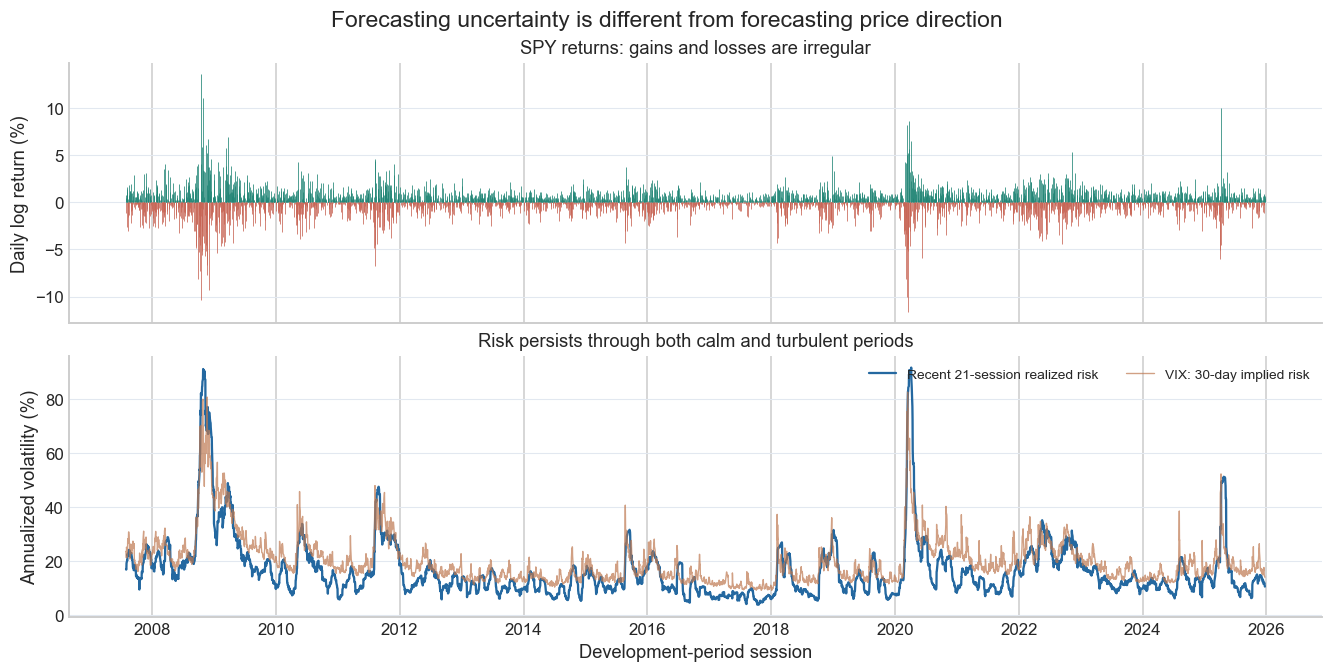

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, layout="constrained")
returns = 100 * development.spy_log_return
axes[0].vlines(
    development.index,
    0,
    returns,
    colors=np.where(returns >= 0, "#218575", "#C86555"),
    linewidth=0.5,
)
axes[0].set(title="SPY returns: gains and losses are irregular", ylabel="Daily log return (%)")
axes[1].plot(
    development.index,
    development.rv21,
    color=COLORS["Random Forest"],
    label="Recent 21-session realized risk",
)
axes[1].plot(
    development.index,
    prices.loc[development.index, "VIX_Close"],
    color=COLORS["Recent 5-session risk"],
    alpha=0.7,
    linewidth=0.9,
    label="VIX: 30-day implied risk",
)
axes[1].set(
    title="Risk persists through both calm and turbulent periods",
    ylabel="Annualized volatility (%)",
    xlabel="Development-period session",
)
axes[1].legend(frameon=False, ncol=2, fontsize=9)
for ax in axes:
    plot_style(ax)
fig.suptitle(
    "Forecasting uncertainty is different from forecasting price direction", fontsize=15
)
fig.savefig(
    "graphs/01_market_history.png", dpi=160, bbox_inches="tight", facecolor="white"
)
plt.show()

Daily returns include sharp moves in both directions. Realized risk and VIX remain elevated across some consecutive sessions, which motivates forecasting risk over a short horizon.

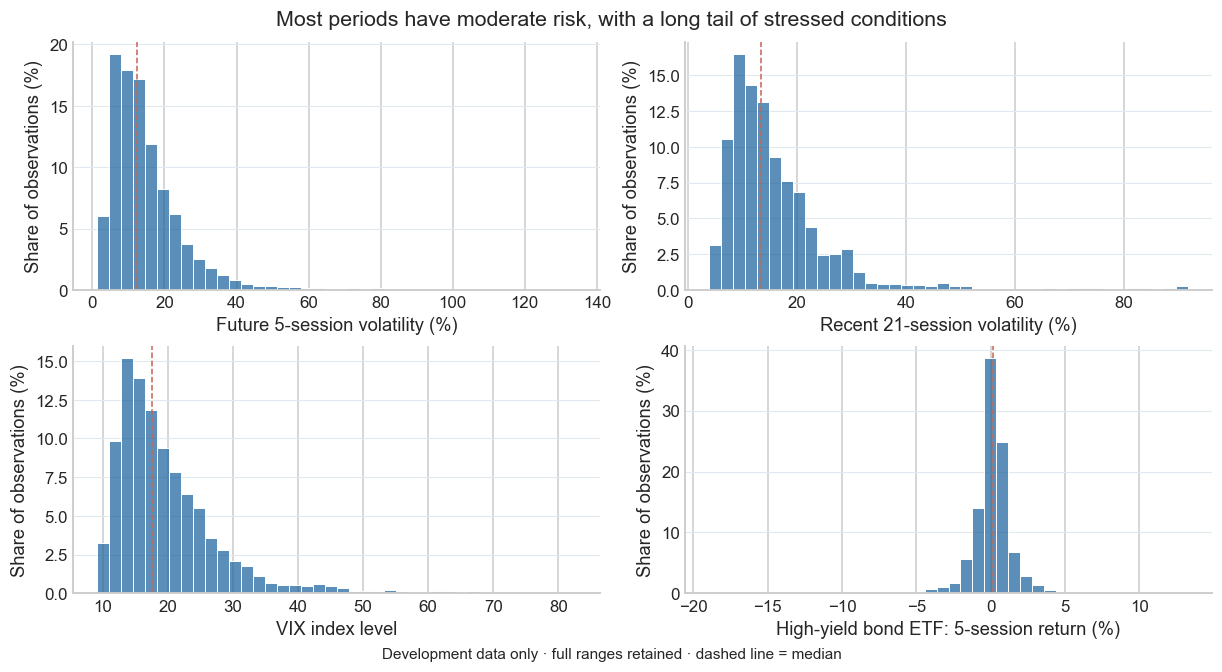

In [19]:
columns = ["future_rv5", "rv21", "log_vix", "hyg_return5"]
labels = [
    "Future 5-session volatility (%)",
    "Recent 21-session volatility (%)",
    "VIX index level",
    "High-yield bond ETF: 5-session return (%)",
]
fig, axes = plt.subplots(2, 2, figsize=(11, 6), layout="constrained")
for ax, column, label in zip(axes.flat, columns, labels):
    values = np.exp(development[column]) if column == "log_vix" else development[column]
    sns.histplot(values, bins=40, stat="percent", color=COLORS["Random Forest"], ax=ax)
    ax.axvline(values.median(), color="#C86555", linestyle="--", linewidth=1)
    ax.set(xlabel=label, ylabel="Share of observations (%)")
    plot_style(ax)
fig.suptitle(
    "Most periods have moderate risk, with a long tail of stressed conditions", fontsize=14
)
fig.supxlabel(
    "Development data only · full ranges retained · dashed line = median", fontsize=10
)
fig.savefig(
    "graphs/02_distributions.png", dpi=160, bbox_inches="tight", facecolor="white"
)
plt.show()

Risk measures have long right tails, which motivates the log transformations in Ridge. We retain extreme periods because predicting stressed conditions is part of the question; neither normality nor constant market conditions is assumed.

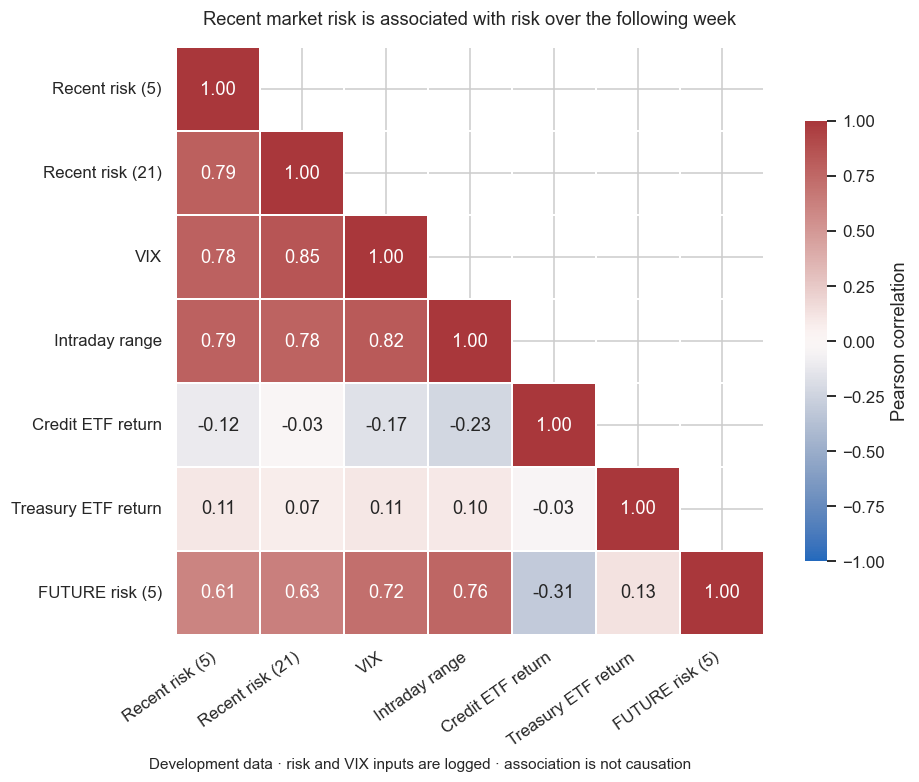

In [20]:
cols = ["log_rv5", "log_rv21", "log_vix", "range5", "hyg_return5", "ief_return5", "future_rv5"]
labels = [
    "Recent risk (5)",
    "Recent risk (21)",
    "VIX",
    "Intraday range",
    "Credit ETF return",
    "Treasury ETF return",
    "FUTURE risk (5)",
]
corr = development[cols].corr()
fig, ax = plt.subplots(figsize=(9, 7), layout="constrained")
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",
    mask=np.triu(np.ones_like(corr, dtype=bool), 1),
    square=True,
    linewidths=1,
    linecolor="white",
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={"label": "Pearson correlation", "shrink": 0.75},
    ax=ax,
)
ax.set_title("Recent market risk is associated with risk over the following week", pad=15)
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)
fig.supxlabel(
    "Development data · risk and VIX inputs are logged · association is not causation",
    fontsize=10,
)
fig.savefig(
    "graphs/03_correlations.png", dpi=160, bbox_inches="tight", facecolor="white"
)
plt.show()

The risk measures are correlated with one another, so the inputs contain overlapping information. These associations do not establish separate causal effects.

#### How current conditions relate to future risk

For each predictor, the observations are divided into ten equally sized groups from low to high. The line shows median future volatility, while the shaded area shows the middle 50% of outcomes.

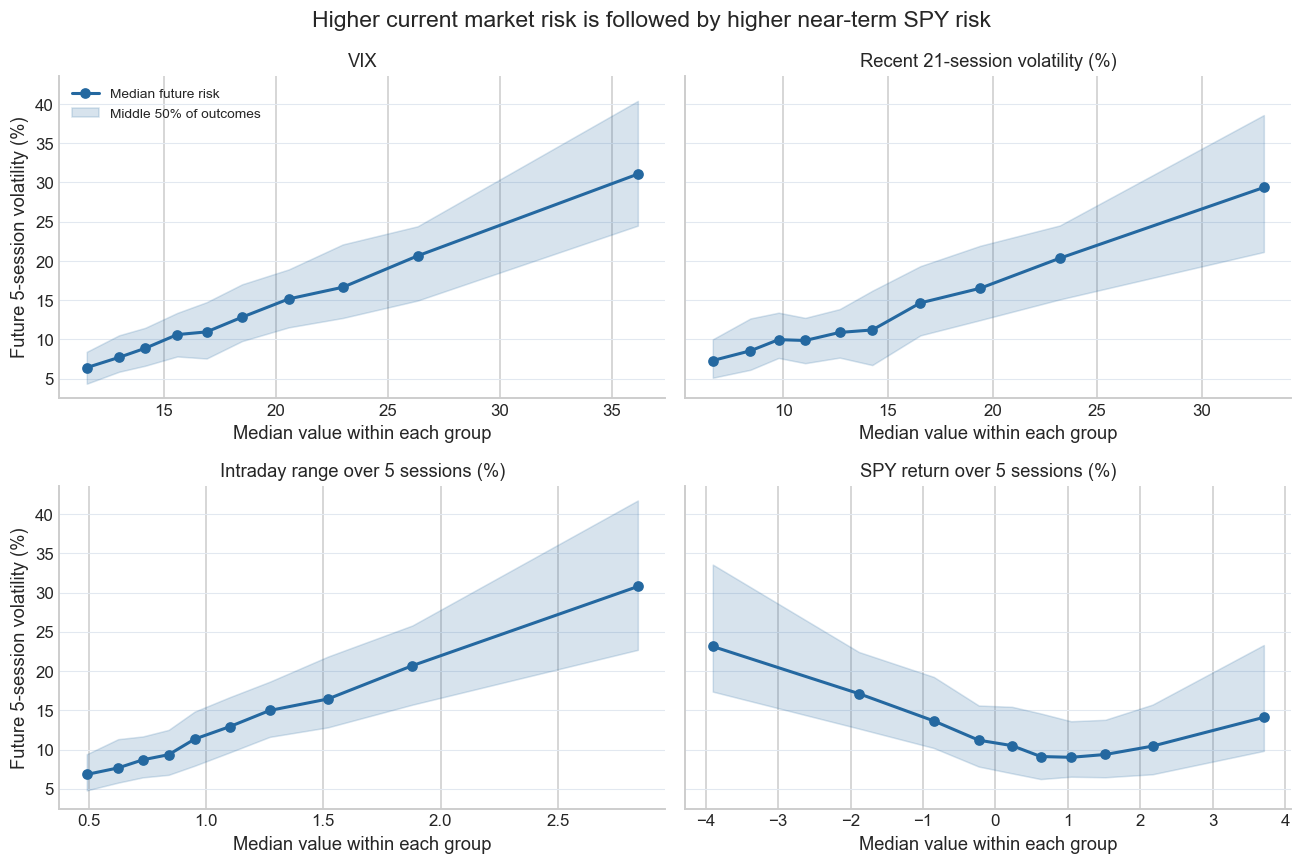

In [21]:
predictors = {
    "VIX": np.exp(development["log_vix"]),
    "Recent 21-session volatility (%)": development["rv21"],
    "Intraday range over 5 sessions (%)": development["range5"],
    "SPY return over 5 sessions (%)": development["spy_return5"],
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

for ax, (label, values) in zip(axes.flat, predictors.items()):
    groups = pd.DataFrame({"Current value": values, "Future risk": development["future_rv5"]})
    groups["Group"] = pd.qcut(groups["Current value"], 10, labels=False)

    summary = groups.groupby("Group").agg(
        current_value=("Current value", "median"),
        future_median=("Future risk", "median"),
        lower_quartile=("Future risk", lambda values: values.quantile(0.25)),
        upper_quartile=("Future risk", lambda values: values.quantile(0.75)),
    )

    ax.plot(
        summary["current_value"],
        summary["future_median"],
        color=COLORS["Random Forest"],
        marker="o",
        linewidth=2,
        label="Median future risk",
    )
    ax.fill_between(
        summary["current_value"],
        summary["lower_quartile"],
        summary["upper_quartile"],
        color=COLORS["Random Forest"],
        alpha=0.18,
        label="Middle 50% of outcomes",
    )
    ax.set(title=label, xlabel="Median value within each group")
    plot_style(ax)

axes[0, 0].set_ylabel("Future 5-session volatility (%)")
axes[1, 0].set_ylabel("Future 5-session volatility (%)")
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("Higher current market risk is followed by higher near-term SPY risk", fontsize=15)
fig.tight_layout()
fig.savefig("graphs/04_relationships.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

Future median volatility rises from **6.4% to 31.1%** across the VIX groups, and similar upward patterns appear for recent volatility and intraday range. Recent SPY return behaves differently: the highest future risk follows the largest recent declines. These relationships describe association, not causation.

### 5. Models, Baselines, and Tuning

We compare two regression models from class:

1. **Ridge Regression** is a regularized linear model. We tune nine alpha values, and scaling is learned inside each training fold.
2. **Random Forest Regressor** can learn nonlinear patterns. We tune tree depth, minimum leaf size, and feature sampling.

Two simple forecasts provide context: recent 5-session volatility and recent 21-session volatility. Every model and baseline is evaluated on the same four chronological validation folds. The 2026 holdout remains unopened until model selection is complete.

#### 5.1 Ridge Regression

Alpha controls the strength of regularization. We select the value with the lowest average validation RMSE.

In [22]:
X_train = development[FEATURES]
y_train = development["future_rv5"]
splits = cv_splits(development)

# The pipeline scales each training fold before fitting Ridge.
ridge_model = TransformedTargetRegressor(
    regressor=make_pipeline(StandardScaler(), Ridge()),
    func=np.log,
    inverse_func=np.exp,
)

ridge_search = GridSearchCV(
    ridge_model,
    {"regressor__ridge__alpha": np.logspace(-3, 5, 9)},
    cv=splits,
    scoring="neg_root_mean_squared_error",
    n_jobs=2,
    return_train_score=True,
)
ridge_search.fit(X_train, y_train);

#### 5.2 Random Forest Regressor

The forest uses 250 trees and seed 402. Larger leaves and limited depth can reduce overfitting.

In [23]:
forest_model = RandomForestRegressor(
    n_estimators=250,
    random_state=SEED,
    n_jobs=1,
)

forest_grid = {
    "max_depth": [3, 8, None],
    "min_samples_leaf": [5, 25, 75],
    "max_features": [0.7, 1.0],
}

forest_search = GridSearchCV(
    forest_model,
    forest_grid,
    cv=splits,
    scoring="neg_root_mean_squared_error",
    n_jobs=2,
    return_train_score=True,
)
forest_search.fit(X_train, y_train);

#### 5.3 Validation Comparison

In [24]:
searches = {
    "Ridge": ridge_search,
    "Random Forest": forest_search,
}

# Score both persistence baselines on the same validation folds.
baseline_rows = []
for name, column in {
    "Recent 5-session risk": "rv5",
    "Recent 21-session risk": "rv21",
}.items():
    for fold, (_, valid_rows) in enumerate(splits, start=1):
        actual = development.iloc[valid_rows]["future_rv5"]
        predicted = development.iloc[valid_rows][column]
        rmse = np.sqrt(mean_squared_error(actual, predicted))
        baseline_rows.append({"Model": name, "Fold": fold, "RMSE": rmse})

baseline_scores = pd.DataFrame(baseline_rows)
selected_baseline = baseline_scores.groupby("Model")["RMSE"].mean().idxmin()

tuning_summary = pd.DataFrame({
    name: {
        "CV RMSE": -search.best_score_,
        "Best parameters": search.best_params_,
    }
    for name, search in searches.items()
}).T
selected_model = tuning_summary["CV RMSE"].idxmin()

display(tuning_summary)
print("Selected model:", selected_model)
print("Selected baseline:", selected_baseline)

,CV RMSE,Best parameters
Ridge,7.04024,{'regressor__ridge__alpha': 10.0}
Random Forest,7.001343,"{'max_depth': None, 'max_features': 0.7, 'min_..."


Selected model: Random Forest
Selected baseline: Recent 5-session risk


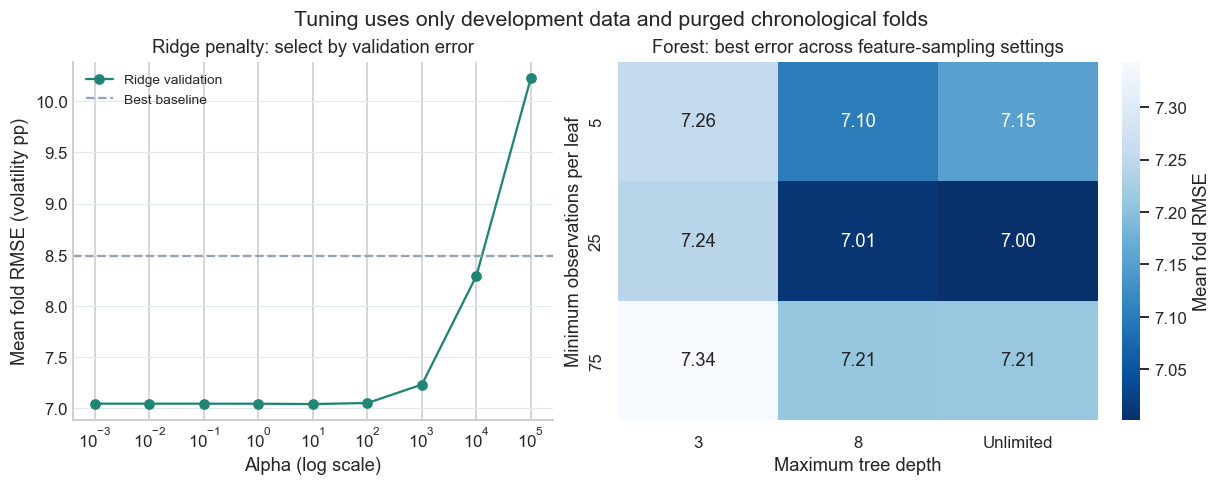

In [25]:
ridge_results = pd.DataFrame(ridge_search.cv_results_)
forest_results = pd.DataFrame(forest_search.cv_results_)
forest_results["RMSE"] = -forest_results["mean_test_score"]
forest_results["Depth"] = forest_results["param_max_depth"].map(
    lambda value: "Unlimited" if pd.isna(value) else str(int(value))
)

forest_heatmap = forest_results.pivot_table(
    index="param_min_samples_leaf",
    columns="Depth",
    values="RMSE",
    aggfunc="min",
).reindex(columns=["3", "8", "Unlimited"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), layout="constrained")

axes[0].semilogx(
    ridge_results["param_regressor__ridge__alpha"].astype(float),
    -ridge_results["mean_test_score"],
    marker="o",
    color=COLORS["Ridge"],
    label="Ridge validation",
)
axes[0].axhline(
    baseline_scores.groupby("Model")["RMSE"].mean().min(),
    color="#94A3B8",
    linestyle="--",
    label="Best baseline",
)
axes[0].set(
    title="Ridge penalty: select by validation error",
    xlabel="Alpha (log scale)",
    ylabel="Mean fold RMSE (volatility pp)",
)
axes[0].legend(frameon=False, fontsize=9)
plot_style(axes[0])

sns.heatmap(
    forest_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Blues_r",
    cbar_kws={"label": "Mean fold RMSE"},
    ax=axes[1],
)
axes[1].set(
    title="Forest: best error across feature-sampling settings",
    xlabel="Maximum tree depth",
    ylabel="Minimum observations per leaf",
)

fig.suptitle("Tuning uses only development data and purged chronological folds", fontsize=14)
fig.savefig("graphs/05_tuning.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

Random Forest narrowly leads Ridge in validation (**7.001 versus 7.040 percentage points RMSE**). Both improve on the selected 5-session baseline (**8.483**). Ridge selects alpha 10, while the forest selects unlimited depth, 25 observations per leaf, and 70% feature sampling. The larger leaf size still limits tree complexity.

### 6. Final Evaluation on the 2026 Holdout

The selected model and baseline are now fixed. The holdout contains 169 forecast dates with complete five-session outcomes. RMSE emphasizes large misses, MAE measures the typical absolute miss, R-squared compares forecasts with the test mean, and QLIKE penalizes poor variance forecasts.

In [26]:
holdout_prices = pd.read_csv(
    "data/market_holdout.csv",
    index_col="Date",
    parse_dates=True,
)

# Add only dates that come after the development file.
all_prices = pd.concat([
    prices,
    holdout_prices.loc[holdout_prices.index > prices.index.max()],
])
sessions = trading_sessions(all_prices.index.min(), all_prices.index.max())
excluded_dates = all_prices.index.difference(sessions)
all_prices = all_prices.reindex(sessions).rename_axis("Date")

assert np.isfinite(all_prices.to_numpy()).all()
assert (all_prices.drop(columns="SPY_Volume") > 0).all().all()
assert (all_prices["SPY_High"] >= all_prices["SPY_Low"]).all()
assert (all_prices["SPY_Volume"] >= 0).all()

full_frame = make_features(all_prices)
fresh_test = modeling_rows(full_frame).loc["2026-01-02":]
assert development["target_end"].max() < fresh_test.index.min()

print("Excluded exchange holidays:", [str(date.date()) for date in excluded_dates])
print(f"Test sample: {len(fresh_test)} forecast dates")

Excluded exchange holidays: ['2026-05-25', '2026-09-07']
Test sample: 169 forecast dates


In [27]:
def regression_scores(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    # QLIKE compares realized and predicted variance.
    variance_ratio = (
        np.maximum(actual, 1e-8) ** 2
        / np.maximum(predicted, 1e-8) ** 2
    )
    return {
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "MAE": mean_absolute_error(actual, predicted),
        "R2": r2_score(actual, predicted),
        "QLIKE": np.mean(variance_ratio - np.log(variance_ratio) - 1),
    }


training_predictions = {
    "Recent 5-session risk": development["rv5"].to_numpy(),
    "Recent 21-session risk": development["rv21"].to_numpy(),
    "Ridge": ridge_search.predict(development[FEATURES]),
    "Random Forest": forest_search.predict(development[FEATURES]),
}
test_predictions = {
    "Recent 5-session risk": fresh_test["rv5"].to_numpy(),
    "Recent 21-session risk": fresh_test["rv21"].to_numpy(),
    "Ridge": ridge_search.predict(fresh_test[FEATURES]),
    "Random Forest": forest_search.predict(fresh_test[FEATURES]),
}

comparison_rows = []
for sample, data, predictions in [
    ("Training", development, training_predictions),
    ("Fresh test", fresh_test, test_predictions),
]:
    baseline_error = mean_squared_error(
        data["future_rv5"], predictions[selected_baseline]
    )
    for name, predicted in predictions.items():
        metrics = regression_scores(data["future_rv5"], predicted)
        comparison_rows.append({
            "Model": name,
            "Sample": sample,
            **metrics,
            "MSE skill": 1 - metrics["RMSE"] ** 2 / baseline_error,
        })

comparison = pd.DataFrame(comparison_rows)
display(comparison.set_index(["Model", "Sample"]).round(3))

,,RMSE,MAE,R2,QLIKE,MSE skill
Model,Sample,,,,,
Recent 5-session risk,Training,9.325,6.174,0.449,1.043,-0.000
Recent 21-session risk,Training,9.588,6.070,0.418,0.588,-0.057
Ridge,Training,8.004,4.741,0.594,0.436,0.263
Random Forest,Training,6.531,4.046,0.730,0.257,0.509
Recent 5-session risk,Fresh test,6.166,4.622,-0.545,0.860,0.000
Recent 21-session risk,Fresh test,5.708,4.671,-0.324,0.413,0.143
Ridge,Fresh test,4.216,3.195,0.278,0.275,0.533
Random Forest,Fresh test,4.291,3.454,0.252,0.260,0.516


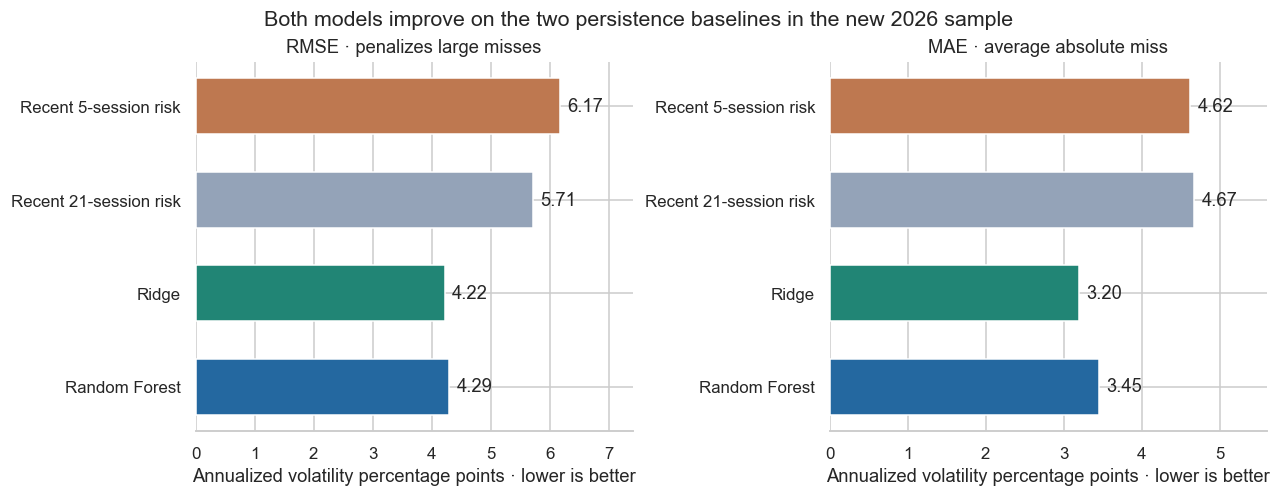

In [28]:
model_order = [
    "Recent 5-session risk",
    "Recent 21-session risk",
    "Ridge",
    "Random Forest",
]
test_scores = (
    comparison.query("Sample == 'Fresh test'")
    .set_index("Model")
    .loc[model_order]
)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), layout="constrained")
for ax, metric, title in zip(
    axes,
    ["RMSE", "MAE"],
    ["RMSE · penalizes large misses", "MAE · average absolute miss"],
):
    bars = ax.barh(
        model_order,
        test_scores[metric],
        color=[COLORS[name] for name in model_order],
        height=0.6,
    )
    ax.bar_label(bars, fmt="%.2f", padding=5)
    ax.set(
        title=title,
        xlabel="Annualized volatility percentage points · lower is better",
        xlim=(0, test_scores[metric].max() * 1.2),
    )
    ax.invert_yaxis()
    sns.despine(ax=ax, left=True)

fig.suptitle(
    "Both models improve on the two persistence baselines in the new 2026 sample",
    fontsize=14,
)
fig.savefig("graphs/06_test_errors.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

Both models beat both baselines. Ridge has the lowest test RMSE (**4.216**) and MAE (**3.195**), while Random Forest has slightly better QLIKE (**0.260 versus 0.275**). Random Forest remains the selected model because it won during validation; switching after seeing test results would use the holdout for model selection.

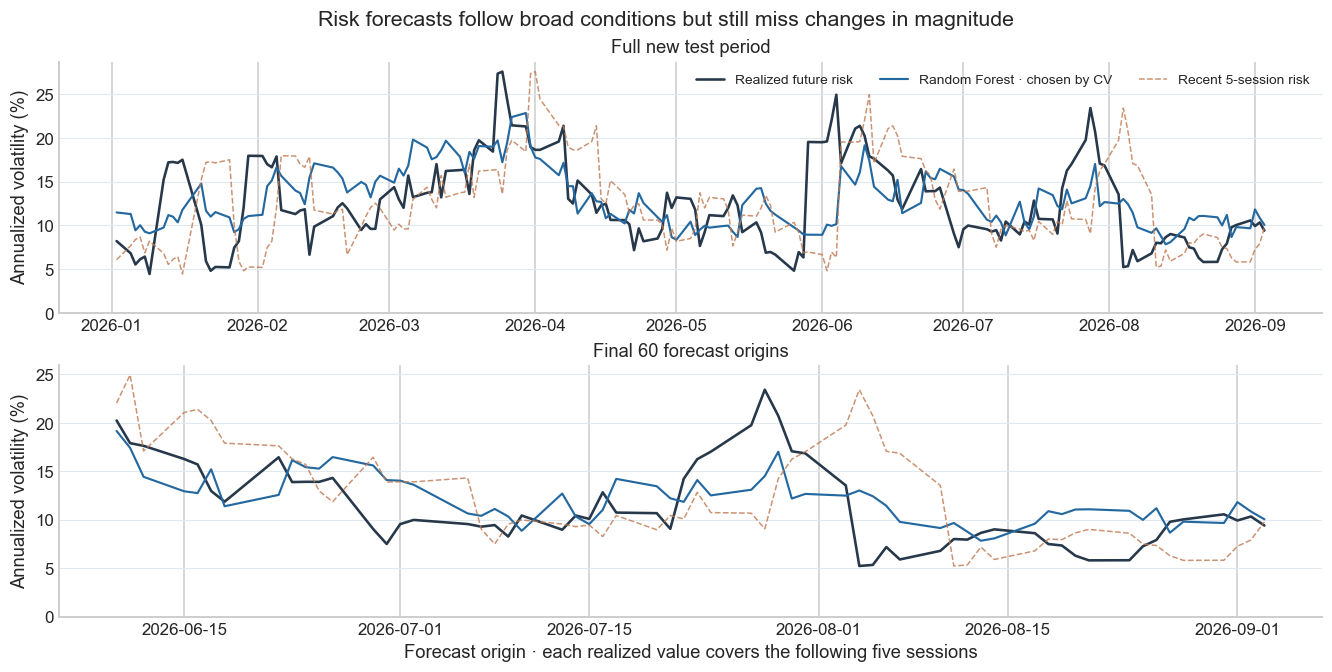

In [29]:
test_table = pd.DataFrame(test_predictions, index=fresh_test.index)
test_table["future_rv5"] = fresh_test["future_rv5"]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), layout="constrained")
windows = [slice(None), slice(-60, None)]
titles = ["Full new test period", "Final 60 forecast origins"]

for ax, window, title in zip(axes, windows, titles):
    subset = test_table.iloc[window]
    ax.plot(subset.index, subset["future_rv5"],
            color=COLORS["Actual"], linewidth=1.7,
            label="Realized future risk")
    ax.plot(subset.index, subset[selected_model],
            color=COLORS[selected_model], linewidth=1.4,
            label=f"{selected_model} · chosen by CV")
    ax.plot(subset.index, subset[selected_baseline],
            color=COLORS[selected_baseline], linewidth=1,
            alpha=0.8, linestyle="--", label=selected_baseline)
    ax.set(title=title, ylabel="Annualized volatility (%)", ylim=(0, None))
    plot_style(ax)

axes[0].legend(frameon=False, ncol=3, fontsize=9)
axes[-1].set_xlabel("Forecast origin · each realized value covers the following five sessions")
fig.suptitle(
    "Risk forecasts follow broad conditions but still miss changes in magnitude",
    fontsize=14,
)
fig.savefig("graphs/07_test_predictions.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

The forest follows broad changes in risk but misses several sudden increases and decreases. Each realized value covers the five sessions after its forecast date.

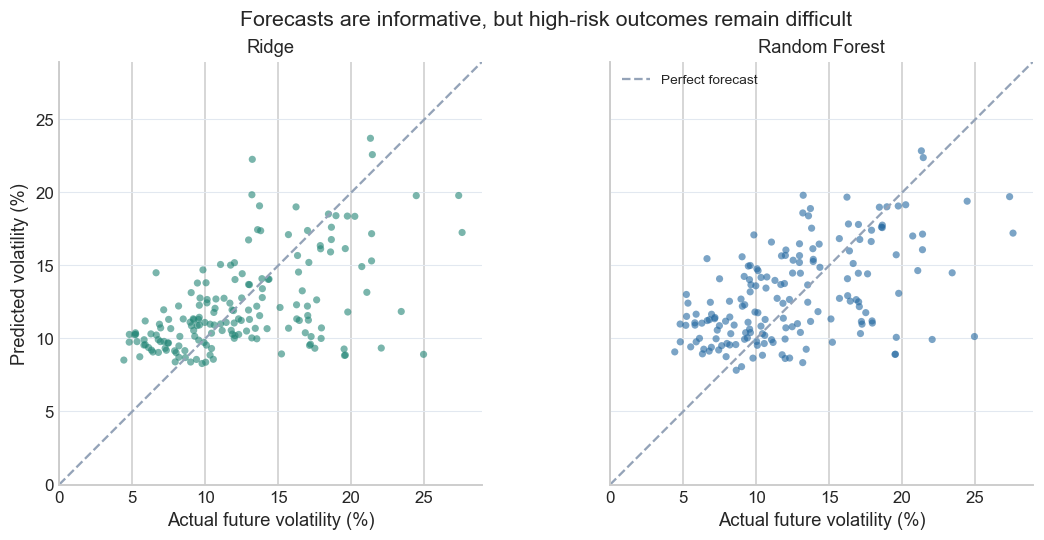

In [30]:
upper_limit = test_table[["future_rv5", "Ridge", "Random Forest"]].max().max() * 1.05

fig, axes = plt.subplots(
    1, 2, figsize=(10, 4.8),
    sharex=True, sharey=True,
    layout="constrained",
)
for ax, name in zip(axes, ["Ridge", "Random Forest"]):
    ax.scatter(
        test_table["future_rv5"],
        test_table[name],
        s=22,
        alpha=0.6,
        color=COLORS[name],
        edgecolors="none",
    )
    ax.plot([0, upper_limit], [0, upper_limit],
            color="#94A3B8", linestyle="--", label="Perfect forecast")
    ax.set(
        title=name,
        xlabel="Actual future volatility (%)",
        xlim=(0, upper_limit),
        ylim=(0, upper_limit),
    )
    ax.set_aspect("equal", adjustable="box")
    plot_style(ax)

axes[0].set_ylabel("Predicted volatility (%)")
axes[1].legend(frameon=False, fontsize=9)
fig.suptitle("Forecasts are informative, but high-risk outcomes remain difficult", fontsize=14)
fig.savefig("graphs/08_calibration.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

The forecasts contain useful information, but both models tend to miss high-risk outcomes. Random Forest training R-squared is **0.730**, compared with **0.252** on the test set. This gap suggests some overfitting, although the development and test periods also have different volatility distributions.

### 7. Dependence, Uncertainty, and Stressed Periods

Five-session targets overlap, so the 169 forecasts are not independent weekly experiments. We use a moving-block bootstrap that preserves local dependence and repeat the comparison using every fifth forecast date, giving 34 non-overlapping outcomes.

In [31]:
def block_skill_interval(actual, predicted, baseline,
                         block_length=20, repeats=2000):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    baseline = np.asarray(baseline)
    rng = np.random.default_rng(SEED)
    sample_size = len(actual)
    skill_values = []

    for _ in range(repeats):
        starts = rng.integers(
            0,
            sample_size - block_length + 1,
            size=int(np.ceil(sample_size / block_length)),
        )
        indices = np.concatenate([
            np.arange(start, start + block_length)
            for start in starts
        ])[:sample_size]

        model_mse = mean_squared_error(actual[indices], predicted[indices])
        baseline_mse = mean_squared_error(actual[indices], baseline[indices])
        skill_values.append(1 - model_mse / baseline_mse)

    return np.quantile(skill_values, [0.025, 0.975])


skill_interval = block_skill_interval(
    fresh_test["future_rv5"],
    test_predictions[selected_model],
    test_predictions[selected_baseline],
)
nonoverlap = test_table.iloc[::5]

print(
    "Random Forest MSE skill: 51.6%; "
    f"approximate 95% interval: {100 * skill_interval[0]:.1f}% "
    f"to {100 * skill_interval[1]:.1f}%"
)
print("Non-overlapping forecasts:", len(nonoverlap))

nonoverlap_scores = pd.DataFrame({
    name: regression_scores(nonoverlap["future_rv5"], nonoverlap[name])
    for name in test_predictions
}).T[["RMSE", "MAE", "R2"]]
display(nonoverlap_scores.round(3))

Random Forest MSE skill: 51.6%; approximate 95% interval: 32.0% to 64.2%
Non-overlapping forecasts: 34


,RMSE,MAE,R2
Recent 5-session risk,6.943,5.512,-0.697
Recent 21-session risk,6.167,4.944,-0.339
Ridge,4.640,3.447,0.242
Random Forest,4.532,3.519,0.277


In [32]:
stress_limit = development["future_rv5"].quantile(0.75)
stress_mask = fresh_test["future_rv5"] >= stress_limit
stress_rows = []

for label, mask in {
    "Below stress threshold": ~stress_mask,
    "Stressed": stress_mask,
}.items():
    actual = fresh_test.loc[mask, "future_rv5"]
    predicted = test_predictions[selected_model][mask.to_numpy()]
    metrics = regression_scores(actual, predicted)
    stress_rows.append({
        "Market condition": label,
        "Forecasts": len(actual),
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
    })

stress_results = pd.DataFrame(stress_rows).set_index("Market condition")
print(f"Stress threshold: {stress_limit:.2f}%")
display(stress_results.round(3))

Stress threshold: 19.08%


,Forecasts,RMSE,MAE
Market condition,,,
Below stress threshold,150,3.646,3.065
Stressed,19,7.668,6.527


The non-overlapping comparison still favors the models: Random Forest RMSE is **4.532**, compared with **6.943** for the selected baseline and **6.167** for the 21-session baseline. However, only 19 test outcomes exceed the stress threshold, and forest MAE rises from **3.06** to **6.53** during those periods.

### 8. Interpretation and Limitations

Ridge coefficients show how the log forecast changes when an input moves by one training standard deviation. Random Forest importance shows how much each input reduces impurity across its trees. Neither measure establishes causation, and correlated variables can share importance.

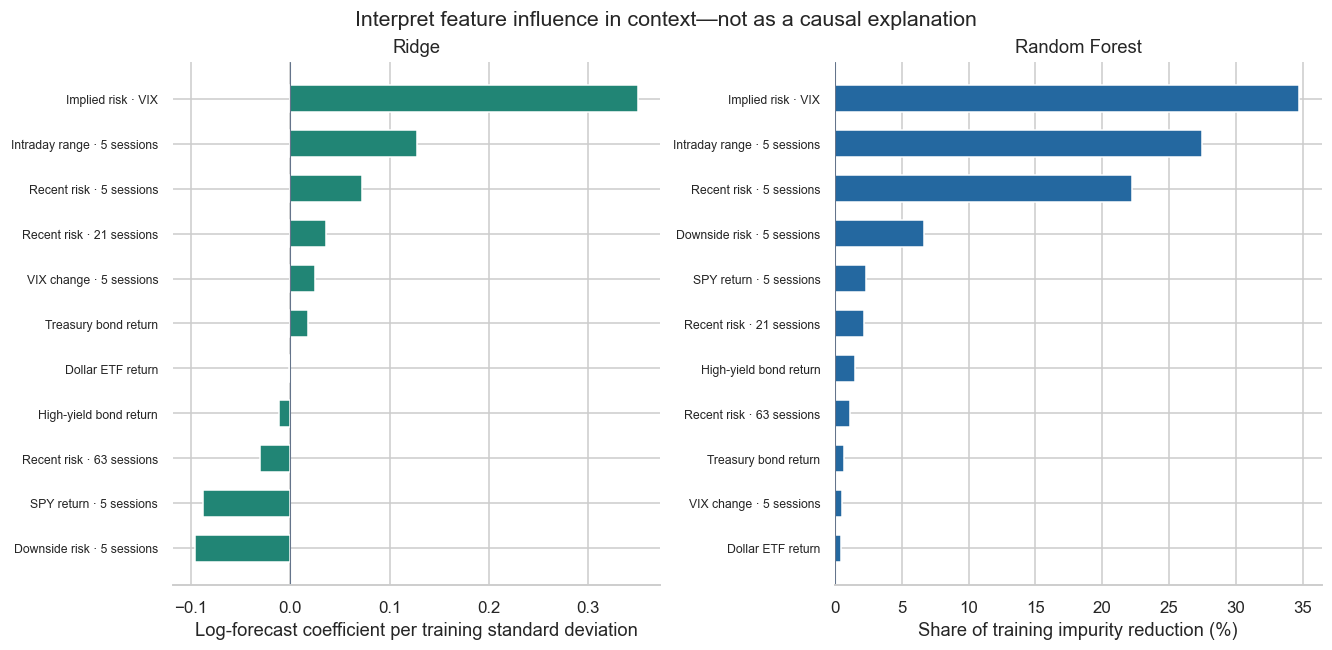

In [33]:
FEATURE_LABELS = {
    "log_rv5": "Recent risk · 5 sessions",
    "log_rv21": "Recent risk · 21 sessions",
    "log_rv63": "Recent risk · 63 sessions",
    "log_vix": "Implied risk · VIX",
    "vix_change5": "VIX change · 5 sessions",
    "spy_return5": "SPY return · 5 sessions",
    "downside_rv5": "Downside risk · 5 sessions",
    "range5": "Intraday range · 5 sessions",
    "hyg_return5": "High-yield bond return",
    "ief_return5": "Treasury bond return",
    "uup_return5": "Dollar ETF return",
}

ridge_coefficients = pd.Series(
    ridge_search.best_estimator_.regressor_.named_steps["ridge"].coef_,
    index=FEATURES,
)
forest_importance = pd.Series(
    forest_search.best_estimator_.feature_importances_,
    index=FEATURES,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.8), layout="constrained")
plot_values = [
    ridge_coefficients.sort_values(),
    (100 * forest_importance).sort_values(),
]

for ax, values, name in zip(axes, plot_values, ["Ridge", "Random Forest"]):
    labels = [FEATURE_LABELS[feature] for feature in values.index]
    ax.barh(labels, values, color=COLORS[name], height=0.6)
    ax.axvline(0, color="#64748B", linewidth=0.7)
    ax.set_title(name)
    ax.tick_params(axis="y", labelsize=8)
    sns.despine(ax=ax, left=True)

axes[0].set_xlabel("Log-forecast coefficient per training standard deviation")
axes[1].set_xlabel("Share of training impurity reduction (%)")
fig.suptitle("Interpret feature influence in context—not as a causal explanation", fontsize=14)
fig.savefig("graphs/09_feature_influence.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

The models rely mostly on risk persistence, VIX, the recent trading range, and recent SPY behavior. Credit, Treasury, and dollar returns contribute less.

The main limitations are:

- Five closing-price returns provide a noisy measure of realized volatility.
- VIX measures implied volatility over a different horizon.
- The test covers one partial year, and overlapping outcomes reduce its effective size.
- Adjusted market histories can be revised.
- The analysis does not measure trading returns, costs, or execution.

These results describe predictive associations rather than causal relationships.

### 9. Conclusion

The more useful question for these data is forecasting the **size of SPY risk over the next five sessions**, rather than tomorrow's return direction. Both Ridge and Random Forest improve on reasonable persistence baselines.

Random Forest is the final model because it had the lowest validation RMSE. On the untouched 2026 holdout, Ridge records a slightly lower RMSE, while Random Forest reduces the selected baseline's RMSE by about **30.4%** and has slightly better QLIKE.

The practical conclusion is cautious: recent risk, VIX, and trading-range information help forecast broad changes in near-term volatility, but sudden risk spikes remain difficult. This model is more suitable as one input to risk monitoring than as a stand-alone trading rule.

### References

- [Kaggle: U.S. Macroeconomic and Market Volatility Features](https://www.kaggle.com/datasets/ashwinprakashml/us-macroeconomic-and-market-volatility-features)
- [Yahoo Finance history through yfinance](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html)
- [Cboe VIX overview and historical data](https://www.cboe.com/tradable-products/vix/vix-historical-data)
- [HYG](https://www.ishares.com/us/products/239565/ishares-iboxx-high-yield-corporate-bond-etf), [IEF](https://www.ishares.com/us/products/239456/ishares-710-year-treasury-bond-etf), and [UUP](https://www.invesco.com/us-rest/contentdetail?contentId=a65d31ae-7cc2-47c9-96f1-78b47809af40&dnsName=us): instrument definitions
- [pandas-market-calendars NYSE calendar](https://github.com/rsheftel/pandas_market_calendars)
- [scikit-learn TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)